# GO enrichment results, exploratory data analysis

Generic and species-agnostic. This notebook reads exactly one input, a
`summary.*.all.tsv` file produced by `enrichment.output.write_results()`,
and knows nothing about which species, metric, or labeling strategy
produced it. Point the Configuration cell at any real run's output
(full-GO or GO-slim, any dataset name) and everything below just works,
since it only relies on the fixed output schema: `go_id, class,
population, observed, expected, fold_enrichment, p_value, q_value,
significance`.

Per the main README's language-constraint principle (section 4): results
at the p<0.01 uncorrected threshold should be read as genes that *tended
to include* a term, not as statistically significant findings. This
notebook is for exploration and sanity-checking, not for generating
publication-ready significance claims on its own.

In [1]:
# ---------------------------------------------------------------------------
# Configuration -- the only cell that needs editing to point this notebook
# at a different run. Everything below is generic.
# ---------------------------------------------------------------------------

# Path to a summary.*.all.tsv file, e.g.
# "../results/GO/summary.CR_3D.PR_gene.all.tsv" or
# "../results/GO_slim/summary.CR_3D.PR_gene.all.tsv"
RESULTS_ALL_TSV = "../results/GO/summary.CR_3D.PR_gene.all.tsv"

# Which column defines "significant" for the purposes of this notebook's
# highlighting -- should match whatever --thresh-type/--thresh the run
# actually used. The 'significance' column in the file already reflects
# this choice, this only controls how p_value vs q_value is plotted below.
SIG_COL = "p_value"  # or "q_value"
SIG_THRESH = 0.01

# How many top terms per class to show in the summary table.
TOP_N = 15

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(RESULTS_ALL_TSV, sep="\t", comment="#")
print(f"Loaded {len(df)} (class, GO term) rows from {RESULTS_ALL_TSV}")
print(f"Classes present: {sorted(df['class'].unique())}")
df.head()

Loaded 2334 (class, GO term) rows from ../results/GO/summary.CR_3D.PR_gene.all.tsv
Classes present: ['High', 'Low']


,go_id,class,population,observed,expected,fold_enrichment,p_value,q_value,significance
0,GO:0003674,High,530,52,49.738462,0.062913,0.602251,1.0,False
1,GO:0003824,High,229,16,21.490769,-0.403798,0.204256,1.0,False
2,GO:0016491,High,42,5,3.941538,0.280002,0.587833,1.0,False
3,GO:1902911,High,1,1,0.093846,0.870590,0.164339,1.0,False
4,GO:1902554,High,1,1,0.093846,0.870590,0.164339,1.0,False


## Summary counts per class

A sanity check before anything else: does the number of significant terms
per class look plausible, or is something suspicious (e.g. every row
identically significant, or zero rows tested at all)?

In [3]:
summary_rows = []
for cls, cls_df in df.groupby("class"):
    n_sig = int(cls_df["significance"].sum())
    n_over = int((cls_df["significance"] & (cls_df["fold_enrichment"] > 0)).sum())
    n_under = int((cls_df["significance"] & (cls_df["fold_enrichment"] < 0)).sum())
    summary_rows.append({
        "class": cls,
        "n_terms_tested": len(cls_df),
        "n_significant": n_sig,
        "n_over": n_over,
        "n_under": n_under,
        "min_p_value": cls_df["p_value"].min(),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

if summary_df["n_significant"].sum() == 0:
    print(
        "No significant terms in any class. Before concluding this is a "
        "real absence of signal, check the min_p_value column above -- if "
        "every class's minimum p_value is close to the significance "
        "threshold rather than close to 1.0, a coarser vocabulary (e.g. "
        "GO-slim) or a different labeling strategy may simply not be "
        "isolating a real, narrower signal, not a broken run."
    )

,class,n_terms_tested,n_significant,n_over,n_under,min_p_value
0,High,1167,3,2,1,0.006091
1,Low,1167,4,4,0,0.002497


## Top terms per class

Sorted by p-value, not filtered to significance only, so a near-miss term
(like a term that narrowly misses the threshold) is still visible.

In [4]:
display_cols = ["go_id", "population", "observed", "expected",
                 "fold_enrichment", "p_value", "q_value", "significance"]

for cls, cls_df in df.groupby("class"):
    print(f"\n--- class: {cls} ---")
    display(cls_df.sort_values("p_value").head(TOP_N)[display_cols])


--- class: High ---


,go_id,population,observed,expected,fold_enrichment,p_value,q_value,significance
84,GO:0046982,15,6,1.407692,1.539704,0.006091,1.0,True
75,GO:0046983,15,6,1.407692,1.539704,0.006091,1.0,True
80,GO:0008152,211,10,19.801538,-0.919187,0.008938,1.0,True
71,GO:0044238,192,9,18.018462,-0.927401,0.016517,1.0,False
114,GO:0030527,14,5,1.313846,1.374670,0.017901,1.0,False
49,GO:0005694,10,4,0.938462,1.367016,0.025548,1.0,False
216,GO:0061024,2,2,0.187692,1.336801,0.038823,1.0,False
78,GO:0009987,301,20,28.247692,-0.477933,0.044337,1.0,False
94,GO:0000785,7,3,0.656923,1.271493,0.046666,1.0,False
37,GO:0005515,129,19,12.106154,0.609756,0.047000,1.0,False



--- class: Low ---


,go_id,population,observed,expected,fold_enrichment,p_value,q_value,significance
1336,GO:0016043,25,9,2.576923,1.483209,0.002497,1.0,True
1408,GO:0022607,16,7,1.649231,1.594426,0.003328,1.0,True
1350,GO:0071840,34,10,3.504615,1.288028,0.004866,1.0,True
1414,GO:0044085,25,8,2.576923,1.331206,0.007939,1.0,True
1428,GO:0006412,49,0,5.050769,-2.597119,0.010276,1.0,False
1425,GO:0160307,49,0,5.050769,-2.597119,0.010276,1.0,False
1550,GO:0022618,4,3,0.412308,1.501946,0.020781,1.0,False
1559,GO:0071826,4,3,0.412308,1.501946,0.020781,1.0,False
1415,GO:0043933,14,5,1.443077,1.296263,0.025342,1.0,False
1409,GO:0065003,14,5,1.443077,1.296263,0.025342,1.0,False


## Volcano-style plot

`fold_enrichment` (x-axis, log2 scale already, per `enrichment.ora`) versus
`-log10(p_value)` (y-axis), one panel per class. Points crossing the
significance threshold are highlighted; everything else stays visible in
grey so the overall shape of the distribution is not lost.

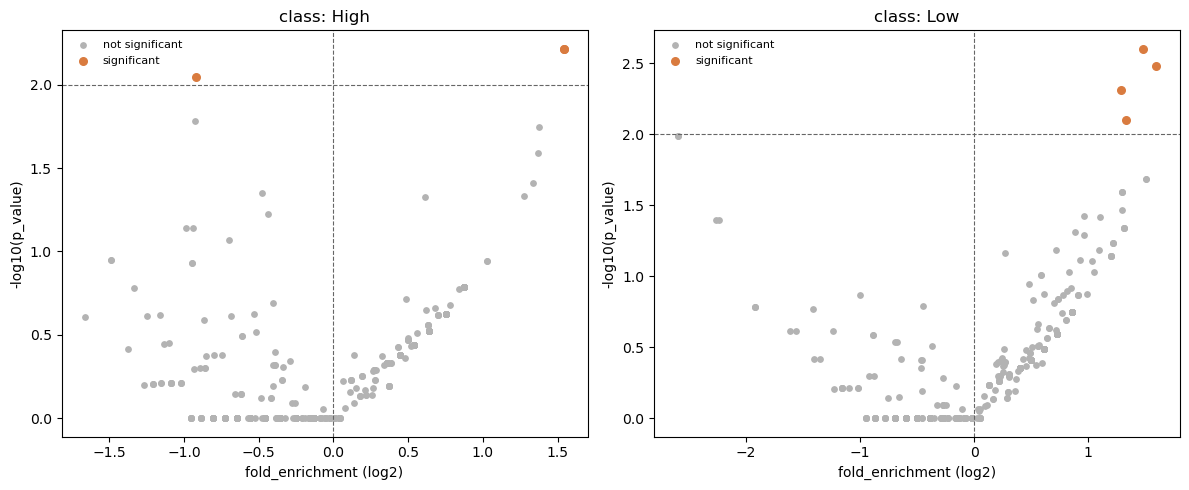

In [5]:
classes = sorted(df["class"].unique())
fig, axes = plt.subplots(1, len(classes), figsize=(6 * len(classes), 5), squeeze=False)
axes = axes[0]

for ax, cls in zip(axes, classes):
    cls_df = df[df["class"] == cls].copy()
    cls_df["neg_log10_p"] = -np.log10(cls_df["p_value"].clip(lower=1e-300))

    not_sig = cls_df[~cls_df["significance"]]
    sig = cls_df[cls_df["significance"]]

    ax.scatter(not_sig["fold_enrichment"], not_sig["neg_log10_p"],
               color="0.7", s=15, label="not significant", zorder=1)
    ax.scatter(sig["fold_enrichment"], sig["neg_log10_p"],
               color="#D97B3F", s=30, label="significant", zorder=2)

    ax.axhline(-np.log10(SIG_THRESH), color="0.4", linestyle="--", linewidth=0.8)
    ax.axvline(0, color="0.4", linestyle="--", linewidth=0.8)
    ax.set_xlabel("fold_enrichment (log2)")
    ax.set_ylabel("-log10(p_value)")
    ax.set_title(f"class: {cls}")
    ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()

## Observed vs expected

A direct check on the raw counts behind each term, useful for catching
anything that looks structurally off (e.g. a population count of 0, which
should never happen since `run_ora` only tests terms with `n_pop > 0`).

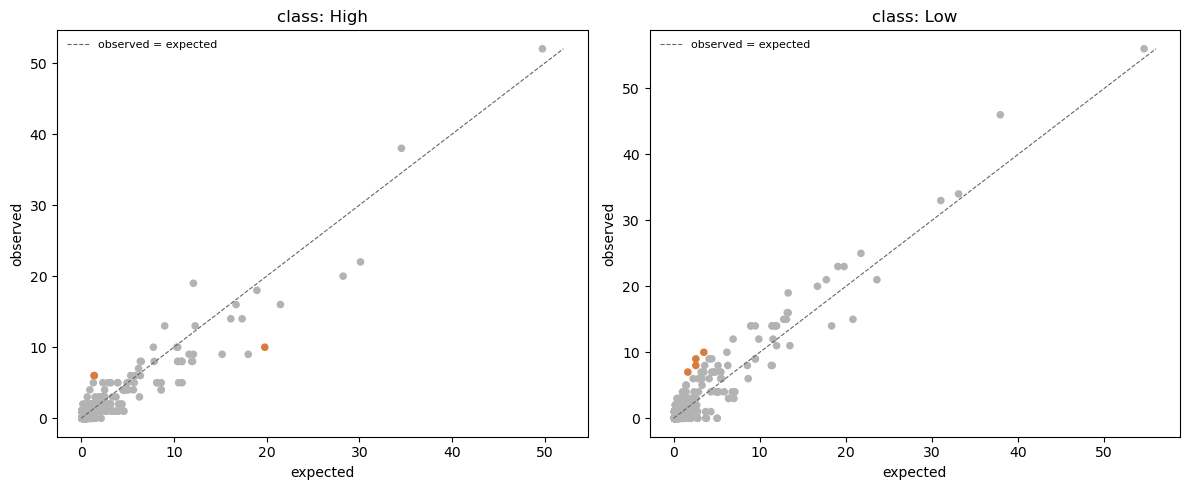

In [6]:
fig, axes = plt.subplots(1, len(classes), figsize=(6 * len(classes), 5), squeeze=False)
axes = axes[0]

for ax, cls in zip(axes, classes):
    cls_df = df[df["class"] == cls]
    colors = np.where(cls_df["significance"], "#D97B3F", "0.7")
    ax.scatter(cls_df["expected"], cls_df["observed"], c=colors, s=20)
    max_val = max(cls_df["expected"].max(), cls_df["observed"].max())
    ax.plot([0, max_val], [0, max_val], color="0.4", linestyle="--", linewidth=0.8,
            label="observed = expected")
    ax.set_xlabel("expected")
    ax.set_ylabel("observed")
    ax.set_title(f"class: {cls}")
    ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()

## Next steps

This notebook is exploration only, it never writes anything to disk. To
look up what a specific GO ID actually means (name, namespace, definition),
use `goatools`'s `GODag` directly against the same `.obo` file the run's
`.godb` was built from, or search the term ID at
https://amigo.geneontology.org/amigo/term/<go_id>.